In [265]:
import numpy as np

# -------------------------
# Linear layer
# -------------------------
class Linear:
    def __init__(self, W, b):
        self.W = W
        self.b = b

    def forward(self, x):
        return x @ self.W.T + self.b


# -------------------------
# BatchNorm layer
# -------------------------
class BatchNorm:
    def __init__(self, num_features, momentum=0.9, eps=1e-5):
        self.num_features = num_features
        self.momentum = momentum
        self.eps = eps
        
        self.gamma = np.ones((1, num_features))
        self.beta  = np.zeros((1, num_features))

        # running stats for inference
        self.running_mean = np.zeros((1, num_features))
        self.running_var  = np.ones((1, num_features))

    def forward(self, x, training=True):
        if training:
            mean = x.mean(axis=0, keepdims=True)
            var  = x.var(axis=0, keepdims=True)

            # update running stats
            self.running_mean = self.momentum*self.running_mean + (1-self.momentum)*mean
            self.running_var  = self.momentum*self.running_var  + (1-self.momentum)*var

            x_norm = (x - mean) / np.sqrt(var + self.eps)
        else:
            # use running stats at test/inference time
            x_norm = (x - self.running_mean) / np.sqrt(self.running_var + self.eps)

        return self.gamma * x_norm + self.beta


# -------------------------
# Dropout layer
# -------------------------
class Dropout:
    def __init__(self, p=0.5):
        self.p = p

    def forward(self, x, training=True):
        if not training or self.p == 0:
            return x
        # inverted dropout scaling (PyTorch compatible)
        mask = (np.random.rand(*x.shape) > self.p) / (1 - self.p)
        return x * mask



# ====================================================
# tests
# ====================================================

# пример входа
X = np.random.randn(4, 5)

print("Input:")
print(X)

# ===== Linear test =====
# создаём параметры САМИ
W = np.random.randn(3, 5) * 0.1
b = np.zeros((1, 3))
lin = Linear(W, b)

print("\nLinear forward:")
print(lin.forward(X))   # expect shape (4,3)

# ===== BatchNorm test =====
bn = BatchNorm(5)
print("\nBatchNorm forward (training):")
print(bn.forward(X, training=True))

print("\nBatchNorm forward (eval):")
print(bn.forward(X, training=False))

# ===== Dropout test =====
drop = Dropout(p=0.5)
print("\nDropout forward (training):")
print(drop.forward(X, training=True))

print("\nDropout forward (eval):")
print(drop.forward(X, training=False))

Input:
[[ 0.30799974 -0.73151377  0.82693078 -0.83549969  0.79892603]
 [-1.21232247 -1.51348142 -1.05311388  0.71816549  0.40694762]
 [ 0.90992816 -0.32960464  0.73886197 -2.36516062  2.57269366]
 [ 0.47234764 -0.87568646  0.76912992  0.2410977   0.82561962]]

Linear forward:
[[ 0.28298781 -0.14352892 -0.07913418]
 [-0.21826386 -0.07379762 -0.24633597]
 [ 0.53670562 -0.37087689 -0.01045495]
 [ 0.09364682 -0.17776177 -0.04458928]]

BatchNorm forward (training):
[[ 0.23570373  0.30781252  0.63815081 -0.232337   -0.42051231]
 [-1.66521837 -1.52877735 -1.73066014  1.07957785 -0.8886238 ]
 [ 0.98831988  1.25176747  0.52718622 -1.52398267  1.6977702 ]
 [ 0.44119476 -0.03080264  0.56532311  0.67674182 -0.38863408]]

BatchNorm forward (eval):
[[ 0.30153222 -0.67340864  0.8100122  -0.76423284  0.69427016]
 [-1.2469384  -1.48949292 -1.10580963  0.75907137  0.29630231]
 [ 0.91460521 -0.25396454  0.72026744 -2.26400189  2.49514101]
 [ 0.468923   -0.82387147  0.75111139  0.29132621  0.72137163]]

D

In [266]:
import random
from PIL import Image
import torch
import torchvision.transforms.functional as F

class BaseTransform:
    def __init__(self, p: float):
        self.p = p

    def __call__(self, img: Image.Image) -> Image.Image:
        if random.random() <= self.p:
            return self.apply(img)
        else:
            return img

    def apply(self, img: Image.Image) -> Image.Image:
        raise NotImplementedError

class Resize(BaseTransform):
    def __init__(self, size):
        self.size = size  # (H,W)
        
    def __call__(self, img):
        return img.resize(self.size, Image.BILINEAR)

class RandomCrop(BaseTransform):
    def __init__(self, p: float, size):
        super().__init__(p)
        self.size = size  # (h, w)

    def apply(self, img: Image.Image):
        return F.crop(img,
                      top=0,
                      left=0,
                      height=self.size[0],
                      width=self.size[1])


class RandomRotate(BaseTransform):
    def __init__(self, p: float, degrees):
        super().__init__(p)
        self.degrees = degrees

    def apply(self, img: Image.Image):
        angle = random.uniform(-self.degrees, self.degrees)
        return F.rotate(img, angle, expand=False)  # expand=False чтобы сохранить размер


class RandomZoom(BaseTransform):
    def __init__(self, p: float, scale_range):
        super().__init__(p)
        self.scale_range = scale_range

    def apply(self, img: Image.Image):
        scale = random.uniform(self.scale_range[0], self.scale_range[1])
        w, h = img.size
        new_w = int(w * scale)
        new_h = int(h * scale)
        return img.resize((new_w, new_h), Image.BILINEAR)


class ToTensor(BaseTransform):
    def __init__(self):
        pass

    def __call__(self, img: Image.Image) -> torch.Tensor:
        return F.to_tensor(img)


class Compose:
    def __init__(self, transforms: list[BaseTransform]):
        self.transforms = transforms

    def __call__(self, img: Image.Image):
        for t in self.transforms:
            img = t(img)
        return img

In [267]:

# создадим маленькое тестовое изображение 10x10
img = Image.new('RGB', (10, 10), color='white')


# создаём трансформации
crop = RandomCrop(p=1.0, size=(5, 5))
rotate = RandomRotate(p=1.0, degrees=30)
zoom = RandomZoom(p=1.0, scale_range=(0.5, 1.5))

# Compose со всеми трансформациями
compose = Compose([crop, rotate, zoom])

# === тест 1: воспроизводимость ===
random.seed(42)
img1 = compose(img)
random.seed(42)
img2 = compose(img)

# сравниваем размеры и пиксели
print("Reproducibility test:", img1.tobytes() == img2.tobytes())  # True → воспроизводимо

# === тест 2: граничные случаи p=0 и p=1 ===
# p=0 → трансформация не применяется
crop0 = RandomCrop(p=0.0, size=(5,5))
rotate0 = RandomRotate(p=0.0, degrees=45)
zoom0 = RandomZoom(p=0.0, scale_range=(0.5,1.5))

compose0 = Compose([crop0, rotate0, zoom0])
img0 = compose0(img)
print("p=0 test, image unchanged:", img0.tobytes() == img.tobytes())  # True

# p=1 → трансформация всегда применяется
crop1 = RandomCrop(p=1.0, size=(5,5))
rotate1 = RandomRotate(p=1.0, degrees=90)
zoom1 = RandomZoom(p=1.0, scale_range=(0.5,1.5))
compose1 = Compose([crop1, rotate1, zoom1])

random.seed(123)
img1_full = compose1(img)
print("p=1 test, image changed:", img1_full.tobytes() != img.tobytes())  # True

# === тест 3: ToTensor ===
tensor_img = ToTensor()(img)
print("ToTensor type:", type(tensor_img))  # torch.Tensor
print("ToTensor shape:", tensor_img.shape)  # [C,H,W]


Reproducibility test: True
p=0 test, image unchanged: True
p=1 test, image changed: True
ToTensor type: <class 'torch.Tensor'>
ToTensor shape: torch.Size([3, 10, 10])


Задание на обучение на датасете с трансформациями

In [268]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import random
import matplotlib.pyplot as plt

Создаём кастомный датасет с трансформациями

In [269]:
class CustomDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        from torchvision.datasets import ImageFolder
        self.dataset = ImageFolder(root=root_dir)
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        img = img.resize((128,128))  # все изображения одного размера
        if self.transform:
            img = self.transform(img)
        img = ToTensor()(img)
        return img, label


# полный датасет
full_dataset = CustomDataset(root_dir='data')

# делим на train/test (80/20)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])


In [270]:
# без трансформаций
train_dataset_noaug = train_dataset

# с трансформациями
p = 0.7
train_transforms = Compose([
    RandomCrop(p=p, size=(128,128)),
    RandomRotate(p=p, degrees=30),
    RandomZoom(p=p, scale_range=(0.8,1.2)),
    Resize((128,128))  # теперь все изображения одинакового размера
])


# применяем трансформации только к train
train_dataset_aug = CustomDataset(
    root_dir='data',
    transform=train_transforms
)

# делим train_dataset_aug на train и test в тех же пропорциях
train_dataset_aug, _ = random_split(train_dataset_aug, [train_size, test_size])

# DataLoader
batch_size = 32
train_loader_noaug = DataLoader(train_dataset_noaug, batch_size=batch_size, shuffle=True)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


Создаем простую модель

In [271]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*32*32, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.fc(self.conv(x))


Обучаем

In [272]:
def train_model(model, train_loader, test_loader, num_epochs=20):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    train_losses, test_losses = [], []
    train_accs, test_accs = [], []

    for epoch in range(num_epochs):
        # train
        model.train()
        running_loss, correct, total = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_losses.append(running_loss / total)
        train_accs.append(correct / total)

        # test
        model.eval()
        running_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                running_loss += loss.item() * imgs.size(0)
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        test_losses.append(running_loss / total)
        test_accs.append(correct / total)

        print(f"Epoch {epoch+1}/{num_epochs}, Train loss: {train_losses[-1]:.4f}, Train acc: {train_accs[-1]:.4f}, Test loss: {test_losses[-1]:.4f}, Test acc: {test_accs[-1]:.4f}")

    return train_losses, test_losses, train_accs, test_accs


num_classes = len(full_dataset.dataset.classes)
model_noaug = SimpleCNN(num_classes)
model_aug = SimpleCNN(num_classes)

# без трансформаций
train_losses_noaug, test_losses_noaug, train_accs_noaug, test_accs_noaug = train_model(model_noaug, train_loader_noaug, test_loader)

# с трансформациями
train_losses_aug, test_losses_aug, train_accs_aug, test_accs_aug = train_model(model_aug, train_loader_aug, test_loader)


Epoch 1/20, Train loss: 2.5400, Train acc: 0.1324, Test loss: 2.1413, Test acc: 0.0874
Epoch 2/20, Train loss: 2.0994, Train acc: 0.1520, Test loss: 2.0396, Test acc: 0.2427
Epoch 3/20, Train loss: 1.9242, Train acc: 0.2892, Test loss: 1.8890, Test acc: 0.2816
Epoch 4/20, Train loss: 1.7795, Train acc: 0.3382, Test loss: 1.8344, Test acc: 0.2816
Epoch 5/20, Train loss: 1.5670, Train acc: 0.4559, Test loss: 1.8483, Test acc: 0.3398
Epoch 6/20, Train loss: 1.3451, Train acc: 0.5172, Test loss: 1.9886, Test acc: 0.2718
Epoch 7/20, Train loss: 1.1433, Train acc: 0.5980, Test loss: 1.9513, Test acc: 0.3689
Epoch 8/20, Train loss: 0.9256, Train acc: 0.7132, Test loss: 2.2464, Test acc: 0.2816
Epoch 9/20, Train loss: 0.7373, Train acc: 0.7574, Test loss: 2.3265, Test acc: 0.2621
Epoch 10/20, Train loss: 0.5784, Train acc: 0.8284, Test loss: 2.2114, Test acc: 0.2913
Epoch 11/20, Train loss: 0.3321, Train acc: 0.9289, Test loss: 2.5072, Test acc: 0.2913
Epoch 12/20, Train loss: 0.2125, Train ac

Графики

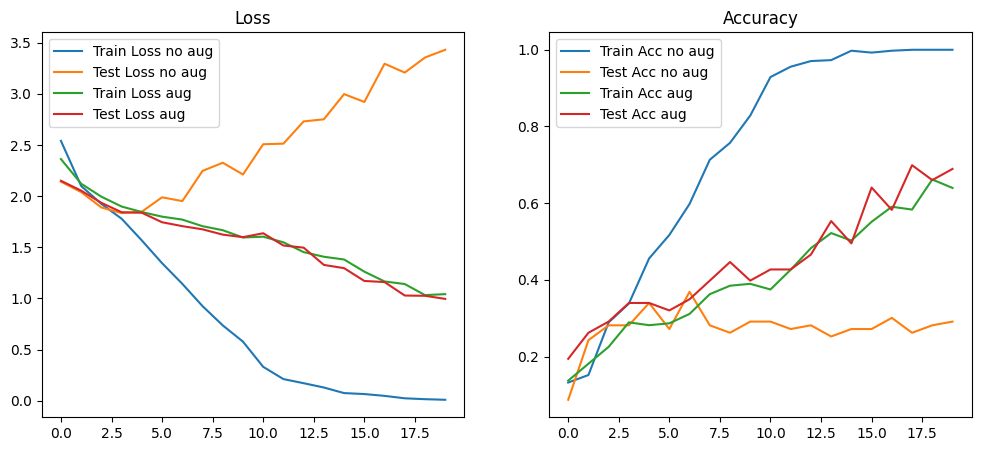

In [273]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(train_losses_noaug, label='Train Loss no aug')
plt.plot(test_losses_noaug, label='Test Loss no aug')
plt.plot(train_losses_aug, label='Train Loss aug')
plt.plot(test_losses_aug, label='Test Loss aug')
plt.title("Loss")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(train_accs_noaug, label='Train Acc no aug')
plt.plot(test_accs_noaug, label='Test Acc no aug')
plt.plot(train_accs_aug, label='Train Acc aug')
plt.plot(test_accs_aug, label='Test Acc aug')
plt.title("Accuracy")
plt.legend()

plt.show()


Видим, что применив аугментации, мы избавились от переобучения, и статистика train стала практически полностью совпадать с тестовой